<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/%5Bno_checkpoints%5DV02_01a_Early_and_Late_Fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early and Late Fusion: Multimodality with RGB + LIDAR Data



Multimodal models are a simple concept with a complex practice. Let's compare different data types and how we can analyze them in a multimodal model with a robotics use case combining regular color images in red, green, and blue (RGB) with LiDAR images captured with a time of flight sensor.

These images were generated with [Nvidia's Omniverse Replicator](https://docs.omniverse.nvidia.com/extensions/latest/ext_replicator/getting_started.html) and are co-registered with one another.

### Task Description

**Goal:** Predict the 3D spatial coordinates of objects in a scene. This is a regression task.

*   **Input Data:** Multimodal data consisting of RGB images and LiDAR point clouds.
*   **Objects to Locate:** Three specific objects: a Cube, a Sphere, and a Torus.
*   **Prediction Target:** The $(x, y, z)$ center coordinates for each of the three objects.
*   **Output:** A vector of 9 values $[x_1, y_1, z_1, x_2, y_2, z_2, x_3, y_3, z_3]$.

#### Learning Objectives

The goals of this notebook are to:
* Explore the properties of LiDAR data
* Compare single modal models
  * Construct an RGB image model
  * Construct a LiDAR model
* Compare multimodal models
  * Construct a late fusion model
  * Construct and early fusion model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms.v2 as transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from PIL import Image
from IPython.display import Image as IPy_img
import matplotlib.colors as colors
import os

## Ground Truth Data

In [ ]:
POSITIONS_DF = pd.read_csv("https://raw.githubusercontent.com/andandandand/practical-computer-vision/refs/heads/main/artifacts/replicator_data_orthogonal_positions.csv")
POSITIONS_DF.head()

,cube_x,cube_y,cube_z,sphere_x,sphere_y,sphere_z,torus_x,torus_y,torus_z
0,-0.059180,-0.762632,4.637073,2.172168,-4.251295,0.112740,-1.016680,2.577287,-0.659820
1,3.852501,2.610654,1.582966,-3.358410,4.437363,-4.714490,1.354207,-3.176319,-1.989396
2,-0.586377,-0.825559,4.393541,-1.258265,1.063964,2.084718,0.209829,-0.261561,-4.296398
3,2.541017,-2.623700,-3.518759,-0.025759,4.889721,-3.133865,2.022122,1.653047,3.616594
4,1.187262,-1.649648,-1.238787,-2.808753,2.319092,-0.563041,3.399651,0.271180,1.989490


## Utils

In [ ]:
IMG_SIZE = 64
BATCH_SIZE = 32
VALID_BATCHES = 10
N = 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# We will use the MSELoss() to perform the regression task.
loss_func = nn.MSELoss()

def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]


def get_color_gradient(c1, c2, c3, n1, n2):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    c3_rgb = np.array(hex_to_RGB(c3))/255
    mix_pcts_c1_c2 = [x/(n1-1) for x in range(n1)]
    mix_pcts_c2_c3 = [x/(n2-1) for x in range(n2)]
    rgb_c1_c2 = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts_c1_c2]
    rgb_c2_c3 = [((1-mix)*c2_rgb + (mix*c3_rgb)) for mix in mix_pcts_c2_c3]
    rgb_colors = rgb_c1_c2 + rgb_c2_c3
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


cmap = colors.ListedColormap(get_color_gradient("#000000", "#76b900", "#f1ffd9", 64, 128))


def format_positions(positions):
    return ['{0: .3f}'.format(x) for x in positions]

def get_outputs(model, batch, inputs_idx):
    inputs = batch[inputs_idx].to(device)
    target = batch[-1].to(device)
    outputs = model(inputs)
    return outputs, target

def print_loss(epoch, loss, outputs, target, is_train=True, is_debug=False):
    loss_type = "Train loss:" if is_train else "Validation loss:"
    print("Epoch", str(epoch), loss_type, f'{loss:.3f}')
    if is_debug:
        print("example pred:", format_positions(outputs[0].tolist()))
        print("example real:", format_positions(target[0].tolist()))


import copy

def train_model_checkpoint(model, optimizer, input_fn,
                           epochs, train_dataloader, valid_dataloader,
                           save_name="best_model.pth", target_idx=-1):

    train_losses = []
    valid_losses = []

    # Initialize best loss to infinity
    best_valid_loss = float('inf')
    # Keep a copy of the initial weights
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0
        for step, batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            target = batch[target_idx].to(device)

            # Unpack inputs based on the input_fn provided
            inputs = input_fn(batch)
            outputs = model(*inputs)

            loss = loss_func(outputs, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss = train_loss / (step + 1)
        train_losses.append(train_loss)

        # --- VALIDATION PHASE ---
        model.eval()
        valid_loss = 0
        with torch.no_grad(): # Turn off gradients for validation to save memory
            for step, batch in enumerate(valid_dataloader):
                target = batch[target_idx].to(device)
                inputs = input_fn(batch)
                outputs = model(*inputs)
                valid_loss += loss_func(outputs, target).item()

        valid_loss = valid_loss / (step + 1)
        valid_losses.append(valid_loss)

        print_loss(epoch, train_loss, outputs, target, is_train=True)
        print_loss(epoch, valid_loss, outputs, target, is_train=False)

        # --- CHECKPOINTING LOGIC ---
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            # Deep copy the model weights in memory
            best_model_wts = copy.deepcopy(model.state_dict())
            # Save to disk
            torch.save(model.state_dict(), save_name)
            print(f"  --> New best validation loss: {best_valid_loss:.4f}. Saved to {save_name}")

    # --- RESTORE BEST WEIGHTS ---
    print(f"Training complete. Loading best weights with loss: {best_valid_loss:.4f}")
    model.load_state_dict(best_model_wts)

    return train_losses, valid_losses

img_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True)
    #Q: Would training benefit from using transforms.Normalize()?
    #Q: How would you compute the mean and standard deviations needed?

])


class ReplicatorDataset(Dataset):
    def __init__(self, root_dir, start_idx, stop_idx):
        self.root_dir = root_dir
        self.rgb_imgs = []
        self.lidar_depths = []
        self.positions = POSITIONS_DF.iloc[start_idx:stop_idx].to_numpy()


        azimuth = np.load(self.root_dir + "azimuth.npy")
        zenith = np.load(self.root_dir + "zenith.npy")
        self.azimuth = torch.from_numpy(azimuth).to(device)
        self.zenith = torch.from_numpy(zenith).to(device)

        for idx in range(start_idx, stop_idx):
            file_number = "{:04d}".format(idx)
            rbg_img = Image.open(self.root_dir + "rgb/" + file_number + ".png")
            rbg_img = img_transforms(rbg_img).to(device)
            self.rgb_imgs.append(rbg_img)

            lidar_depth = np.load(self.root_dir + "lidar/" + file_number + ".npy")
            lidar_depth = torch.from_numpy(lidar_depth).to(torch.float32).to(device)
            self.lidar_depths.append(lidar_depth)

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, idx):
        rbg_img = self.rgb_imgs[idx]
        lidar_depth = self.lidar_depths[idx]
        lidar_xyza = get_torch_xyza(lidar_depth, self.azimuth, self.zenith)

        position = self.positions[idx]
        position = torch.from_numpy(position).to(torch.float32).to(device)

        return rbg_img, lidar_xyza, position


def get_replicator_dataloaders(root_dir):
    train_data = ReplicatorDataset(root_dir, 0, N-VALID_BATCHES*BATCH_SIZE)
    train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    valid_data = ReplicatorDataset(root_dir, N-VALID_BATCHES*BATCH_SIZE, N)
    valid_dataloader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
    return train_data, train_dataloader, valid_data, valid_dataloader


In PyTorch, we can use our GPU in our operations by setting the [device](https://pytorch.org/docs/stable/tensor_attributes.html#torch.device) to `cuda`. The function `torch.cuda.is_available()` will confirm PyTorch can recognize the GPU.

In [ ]:
!nvidia-smi

Thu Nov 20 10:17:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             12W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

## 1.1 The Dataset

Many fields of data science have famous "Hello World" style datasets that can be used to demonstrate a model architecture. Unfortunately, there is no such standard benchmark for multimodal models, so we decided to make such a dataset using [NVIDIA Omniverse](https://www.nvidia.com/en-us/omniverse/).

Real world data collection can be challenging, and so NVIDIA Omniverse is a platform that can be used for creating and simulating virtual copies of real-life objects and locations. These virtual copies are called [Digital Twins](https://www.nvidia.com/en-us/omniverse/solutions/digital-twins/). These digital twins can be used to simulate and capture data that would be difficult, or even impossible, with real world instruments. The process of creating this data is called [Synthetic Data Generation](https://www.nvidia.com/en-us/use-cases/synthetic-data/).

For this first lab, we randomly generated the positions of three objects: a cube, a sphere, or a torus (a.k.a. a donut). What kind of tools could we use to determine the position of the center of these objects? Let's look at our options.

Each of the data types below are generated from the same position of objects. The position is the same across data files of the same file number, in this case, `0163`.

### 1.1.1 RGB Camera Data
The first kind of data are [RGB color images](https://en.wikipedia.org/wiki/RGB_color_model). This could be captured using a camera, such as the one on the back of most smartphones. Let's look at an example.

In [ ]:
from pathlib import Path
DATA_PATH = Path('/gdrive/MyDrive/multimodal_training_workshop/data')

In [ ]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive

Mounted at /gdrive
/gdrive


In [ ]:
os.listdir(DATA_PATH)

['flower_photos.gsheet',
 'cubes_only_single_mode_results.gsheet',
 'flower_photos',
 'replicator_data_cubes',
 'assessment',
 'replicator_data_orthogonal',
 'replicator_data_orthogonal.gz',
 'incomplete_replicator_data_orthogonal',
 'dup_replicator_data_orthogonal',
 'rgb_best.pth']

In [ ]:
os.listdir(DATA_PATH / 'replicator_data_orthogonal')

['azimuth (1).npy',
 'colors.csv',
 'azimuth.npy',
 'positions.csv',
 'zenith.npy',
 'pointcloud',
 'distance',
 'lidar',
 'rgb',
 'colors.gsheet',
 'pcd',
 'pcd.zip']

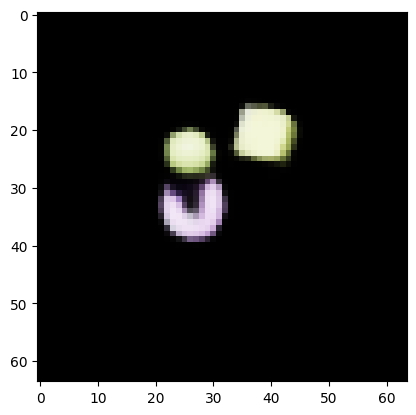

In [ ]:
data_img = Image.open(DATA_PATH / 'replicator_data_orthogonal/rgb/0163.png')
plt.imshow(data_img);

Here, we have an image that's 64 pixels tall and 64 pixels wide. Image data like this is generally analyzed using a [convolutional neural network](https://developer.nvidia.com/discover/convolutional-neural-network). We will be using the same technique in our multimodal models.

### 1.1.2 Distance Image

Since the data is simulated, Omniverse can calculate the distance of each pixel to the camera that is capturing the image. RGB cameras work by recording the light that reflects off of the objects in front of it. Because of that, it can be difficult to gather usable data in low-light situations. By instead using the distance, we can see better in the dark.

However, in the real world, there are not many instruments that can capture this data like in the image below. Because of this, we will not be using them in our multimodal models, but the data is available to help verify our analysis.

In [ ]:
data = np.load(DATA_PATH / 'replicator_data_orthogonal/distance/0163.npy')
plt.imshow(data, cmap=cmap);

### 1.1.3 LiDAR Data

One real world instrument that can capture distance data is a [LiDAR](https://oceanservice.noaa.gov/facts/lidar.html) sensor. LiDAR sensors work by emitting multiple beams of light invisible to the human eye. Thanks to [Ole Rømer](https://en.wikipedia.org/wiki/Ole_R%C3%B8mer) who calculated the speed of light, we can measure how far away something is based on how long it takes to observe the emitted light.

There are many types of LiDAR devices available on the market, but to make a better comparison with RGB data, we simulated 64 by 64 lasers being emitted from the sensor. Because of the shape, we can view it like an image. There will be a little bit of a discrepancy because LiDAR data is collected along a curve, but this 2D projection can still be useful for debugging.

### How LiDAR Data is Processed with Conv2d Operations

## Overview

The key insight is that **LiDAR data is transformed from depth measurements into a 4-channel 2D grid that can be processed like an image**, making it compatible with Conv2d operations.

## The Spherical to Cartesian Coordinates Transformation

There are two main reasons why we start with this "Polar" (Depth/Angle) format instead of raw Cartesian (X, Y, Z) coordinates:

1. **Sensor Physics:** LiDAR sensors don't know "where" a point is in 3D space directly. They only know two things:

* **Where they are looking** (the Azimuth and Zenith angles of the laser).
* **How long it took the light to return** (the Distance/Range). So, the raw data coming off the hardware is naturally in this spherical format.

2. **Compatibility with CNNs (The "Image" Structure)**: This is the most important reason for this notebook. By keeping the data as a 2D grid of depth values (a "Range Image"), we preserve the spatial structure—pixel (0,1) is right next to pixel (0,2). This allows us to use standard 2D Convolutional Neural Networks (CNNs), the exact same technology used for recognizing cats and dogs in photos.

If we just had a list of $(x, y, z)$ points (a "Point Cloud"), we would lose that grid structure and would need much more complex models (like PointNet or 3D Convolutions) to process the data.

### Step 1: Raw LiDAR Data Structure

The raw LiDAR data starts as:
- **Depth measurements**: 64×64 grid where each value is the distance a laser beam traveled
- **Azimuth angles**: 64 values (one per row) - horizontal rotation angles
- **Zenith angles**: 64 values (one per column) - vertical rotation angles

```python
lidar_depth = np.load('lidar/0163.npy')  # Shape: (64, 64)
azimuth = np.load('azimuth.npy')          # Shape: (64,)
zenith = np.load('zenith.npy')            # Shape: (64,)
```

### Step 2: Converting to XYZA Format

The most important transformation happens in `get_torch_xyza()` function:

```python
def get_torch_xyza(lidar_depth, azimuth, zenith):
    # Calculate X coordinate (horizontal position)
    x = lidar_depth * torch.sin(-azimuth[:, None]) * torch.cos(-zenith[None, :])

    # Calculate Y coordinate (forward/backward position)
    y = lidar_depth * torch.cos(-azimuth[:, None]) * torch.cos(-zenith[None, :])

    # Calculate Z coordinate (vertical position)
    z = lidar_depth * torch.sin(-zenith[None, :])

    # Create activation mask (1 if valid return, 0 if max range)
    a = torch.where(lidar_depth < 50.0, torch.ones_like(lidar_depth), torch.zeros_like(lidar_depth))

    # Stack into 4 channels
    xyza = torch.stack((x, y, z, a))  # Shape: (4, 64, 64)
    return xyza
```

**Result**: Transform spherical coordinates (depth, azimuth, zenith) into Cartesian coordinates (x, y, z) plus an activation mask.

## Why This Works for Conv2d

### The Key: Spatial Structure is Preserved

Even though we convert from spherical to Cartesian coordinates, **the 2D grid structure is maintained**:

```
Original LiDAR Grid:              XYZA Grid:
┌─────────────────┐              ┌─────────────────┐
│ depth values    │              │ X   Y   Z   A   │  (4 channels)
│ (64×64)         │   ──────>    │ (4, 64, 64)     │
│                 │              │                 │
└─────────────────┘              └─────────────────┘
```

Each **pixel/cell in the grid** corresponds to a specific laser beam with a fixed (azimuth, zenith) pair. The spatial relationships between neighboring laser beams are preserved in the grid.

### What Each Channel Represents

After transformation, the XYZA data has **4 channels**, just like RGBA images:

1. **X channel** (64×64): Horizontal position of each laser return
2. **Y channel** (64×64): Forward/backward position of each laser return
3. **Z channel** (64×64): Vertical position of each laser return
4. **A channel** (64×64): Binary mask (1 = valid return, 0 = max range/no object)

## The Conv2d Architecture


```python
class Net(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        kernel_size = 3
        self.conv1 = nn.Conv2d(in_ch, 50, kernel_size, padding=1)
        self.conv2 = nn.Conv2d(50, 100, kernel_size, padding=1)
        self.conv3 = nn.Conv2d(100, 200, kernel_size, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(200 * 8 * 8, 1000)
        self.fc2 = nn.Linear(1000, 100)
        self.fc3 = nn.Linear(100, num_positions)
```

### For LiDAR Processing:

```python
xyz_net = Net(4)  # 4 input channels for XYZA
```

**Layer-by-layer processing**:

1. **Input**: `(batch, 4, 64, 64)` - XYZA channels
2. **Conv1 + Pool**: `(batch, 50, 32, 32)` - Extracts low-level geometric features across XYZA
3. **Conv2 + Pool**: `(batch, 100, 16, 16)` - Builds mid-level spatial patterns
4. **Conv3 + Pool**: `(batch, 200, 8, 8)` - High-level geometric understanding
5. **Flatten**: `(batch, 12800)` - Convert to 1D feature vector
6. **FC layers**: `(batch, 9)` - Predict 9 position values (x₁, y₁, z₁, x₂, y₂, z₂, x₃, y₃, z₃)

## What Conv2d Learns on XYZA Data

The convolutional filters learn to detect **geometric patterns** in the point cloud:

### First Conv Layer (Conv1)
Operates on raw XYZA channels to detect:
- **Edges and boundaries**: Where X, Y, or Z changes rapidly between neighboring cells
- **Planar surfaces**: Regions where coordinates change smoothly
- **Object clusters**: Groups of valid returns (A=1) surrounded by empty space (A=0)
- **Cross-channel correlations**: How X, Y, Z relate to each other spatially

Example 3×3 kernel on XYZA:
```
For each position (i, j), the kernel looks at:
┌─────┬─────┬─────┐
│ ... │ ... │ ... │  ← 3×3 neighborhood
├─────┼─────┼─────┤
│ ... │ ij  │ ... │  ← across all 4 channels (X, Y, Z, A)
├─────┼─────┼─────┤
│ ... │ ... │ ... │
└─────┴─────┴─────┘
```

### Deeper Conv Layers (Conv2, Conv3)
Learn higher-level patterns:
- **Object shapes**: Detecting cubes vs. spheres vs. torus based on geometric structure
- **Spatial relationships**: How objects relate to each other in 3D space
- **Distance estimation**: Patterns in Y values that indicate how far objects are
- **Height patterns**: Z-coordinate distributions that indicate object positions

## Why 2D Convolutions Work Despite 3D Data

This might seem counterintuitive: we have 3D point cloud data, so why not use 3D convolutions?

**The answer**: The LiDAR sensor has a **fixed scanning pattern**.

- Each (row, col) in the 64×64 grid corresponds to a specific (azimuth, zenith) angle pair
- Neighboring cells in the grid scan **neighboring directions in space**
- **Local spatial coherence**: Nearby laser beams likely hit the same object or nearby objects

This means:
- A 3×3 kernel processes laser returns from **9 neighboring directions**
- Objects create **contiguous patterns** in the XYZA grid
- Edge detection works: object boundaries show up as discontinuities in X, Y, Z values

## Comparison: RGB vs. XYZA

Both use the same architecture but process different types of spatial patterns:

| Aspect | RGB Image | XYZA LiDAR |
|--------|-----------|------------|
| **Input shape** | `(batch, 4, 64, 64)` RGBA | `(batch, 4, 64, 64)` XYZA |
| **Channels** | Color intensities | 3D coordinates + mask |
| **Conv1 learns** | Edges, textures, colors | Geometric boundaries, surfaces |
| **Mid layers learn** | Object parts, patterns | 3D shape structure, clusters |
| **High layers learn** | Object categories | Spatial relationships, positions |
| **Information type** | Visual appearance | Geometric structure |

## The Dataset's Design Choice


```python
def __getitem__(self, idx):
    rgb_img = self.imgs[idx]              # (4, 64, 64) - RGBA
    lidar_xyza = get_torch_xyza(...)      # (4, 64, 64) - XYZA
    position = self.positions[idx]         # (9,) - targets
    return rgb_img, lidar_xyza, position
```

**Intentional design**: Both modalities have the same shape `(4, 64, 64)`, which allows:
1. **Architecture reuse**: Same CNN can process both modalities
2. **Easy comparison**: Fair evaluation of RGB vs. LiDAR
3. **Simple fusion**: Can concatenate for early fusion: `(8, 64, 64)`

## Early Fusion: Processing Combined XYZA + RGB

```python
def get_mm_early_inputs(batch):
    inputs_rgb = batch[0]      # (batch, 4, 64, 64) - RGBA
    inputs_xyz = batch[1]      # (batch, 4, 64, 64) - XYZA
    inputs_mm_early = torch.cat((inputs_rgb, inputs_xyz), 1)  # Concatenate on channel dim
    return (inputs_mm_early,)  # (batch, 8, 64, 64)
```

**Early fusion network**:
```python
mm_early_net = Net(8)  # 8 input channels: 4 RGBA + 4 XYZA
```

The first Conv2d layer now processes **8 channels simultaneously**:
- Filters can learn correlations between visual appearance (RGB) and geometry (XYZ)
- Example pattern: "When red pixels coincide with a certain X,Y,Z pattern, it's likely a red cube at position P"

## Visualizing What Happens

Let's trace one sample through the LiDAR processing:

```python
# Raw data
lidar_depth[32, 32] = 25.5  # Distance measurement at center
azimuth[32] = 0.0           # Straight ahead (horizontal)
zenith[32] = 0.0            # Level (no vertical angle)

# After get_torch_xyza transformation
x[32, 32] = 25.5 * sin(-0.0) * cos(-0.0) = 0.0    # Centered horizontally
y[32, 32] = 25.5 * cos(-0.0) * cos(-0.0) = 25.5   # 25.5 units forward
z[32, 32] = 25.5 * sin(-0.0) = 0.0                # At sensor height
a[32, 32] = 1.0                                    # Valid return

# XYZA tensor shape: (4, 64, 64)
# Each of the 4 channels contains a full 64×64 grid
```

**When Conv2d processes this**:
- A 3×3 kernel at position (32, 32) looks at 9 neighboring positions
- Across all 4 channels: 3×3×4 = 36 values per filter
- 50 different filters in Conv1 → 50 output channels
- Each filter learns a different geometric pattern detector

## Why This Approach Is Powerful

**Advantages of Conv2d on XYZA**:

1. **Spatial invariance**: Patterns learned at one location work at others (objects can appear anywhere)
2. **Hierarchical features**: Low-level (edges) → mid-level (shapes) → high-level (object locations)
3. **Parameter efficiency**: Much fewer parameters than fully connected layers
4. **Local pattern detection**: 3×3 kernels naturally capture local geometric structure

**For position estimation specifically**:
- Point cloud clusters indicate object presence
- Geometric patterns (flat surface, curve, edge) identify object type
- XYZ coordinate distributions directly relate to position
- A channel helps distinguish objects from background

## Full Pipeline (Summary)

The notebook processes LiDAR with Conv2d by:

1. **Transforming depth to 3D coordinates**: Converting spherical (depth, azimuth, zenith) to Cartesian (X, Y, Z) + activation mask
2. **Preserving 2D grid structure**: Each cell in the 64×64 grid represents a specific laser beam direction
3. **Creating 4-channel representation**: XYZA with shape `(4, 64, 64)`, analogous to RGBA images
4. **Applying standard 2D convolutions**: Same CNN architecture learns geometric patterns instead of visual patterns
5. **Leveraging spatial coherence**: Neighboring cells scan neighboring directions, so local convolution kernels make sense

This elegant design allows the same neural network architecture to process both visual (RGB) and geometric (LiDAR) data, demonstrating that Conv2d is fundamentally about learning **spatially-coherent patterns**, whether those patterns are in color space or coordinate space.

## Key Takeaway

Conv2d operations work on LiDAR data because:
- The data maintains a **regular 2D grid structure** (64×64)
- Each grid cell represents a **fixed scanning direction** (azimuth, zenith pair)
- **Neighboring cells scan neighboring directions**, creating spatial coherence
- The transformation to XYZA preserves this structure while providing **geometric meaning**
- Convolutional kernels can learn **local geometric patterns** just as they learn visual patterns in images




### Understanding Azimuth, Zenith, and Range

Azimuth and zenith (often referred to as **elevation** in lidar contexts) are the two angular coordinates that, along with **range** (distance), allow a lidar sensor to map the world in 3D.

Without these angles, a lidar sensor would only know *how far away* an object is, but not *where* it is located in space.

Here is a detailed breakdown of why they are important:

### 1. Precise 3D Positioning (Coordinate Conversion)
The raw data output from a lidar sensor is in **Spherical Coordinates**: $(r, \theta, \phi)$.
*   **Range ($r$):** The distance to the object (calculated by the time-of-flight of the laser).
*   **Azimuth ($\theta$):** The horizontal angle (left/right position).
*   **Zenith/Elevation ($\phi$):** The vertical angle (up/down position).

To create the 3D point clouds used by autonomous vehicles or surveying software, these spherical coordinates must be converted into **Cartesian Coordinates** ($X, Y, Z$) using trigonometry.
*   **$X$** depends on the cosine of the azimuth and sine of the zenith.
*   **$Y$** depends on the sine of the azimuth and sine of the zenith.
*   **$Z$** depends on the cosine of the zenith.

If the sensor records the azimuth or zenith incorrectly even by a fraction of a degree, the resulting 3D point will be placed in the wrong location, causing "ghosting" or warped maps.

### 2. Determining Resolution and Point Density
The importance of these angles extends to how *frequently* the laser is fired at different angles, which defines the **angular resolution**.

*   **Azimuth Resolution (Horizontal Resolution):** This is determined by how fast the lidar spins (or scans) and how fast the laser pulses. High azimuth resolution is critical for detecting thin objects like signposts or pedestrians at a distance. If the angle between horizontal pulses is too wide, a narrow object might fit perfectly in the gap between two laser beams and never be detected.
*   **Zenith Resolution (Vertical Resolution):** This is determined by the number of lasers (channels) in the sensor (e.g., 16, 32, 64, 128 channels). High zenith resolution allows the sensor to distinguish between objects at different heights, such as differentiating a drivable road surface from a curb or a low-hanging branch.

### 3. Field of View (FOV) Definition
Azimuth and zenith define the boundaries of what the sensor can see:
*   **Azimuth FOV:** Usually $360^\circ$ for spinning mechanical lidars (seeing all around) or limited (e.g., $120^\circ$) for solid-state lidars.
*   **Zenith FOV:** Defines the vertical slice of the world the sensor sees. For example, a sensor with a narrow zenith FOV might see other cars perfectly but fail to see a traffic light overhead or a pothole directly in front of the bumper.

### Summary Table
| Parameter | Definition | Why it is Important |
| :--- | :--- | :--- |
| **Azimuth** | The horizontal angle (0° to 360°). | Tells you if an object is to your left, right, front, or back. |
| **Zenith** | The vertical angle from the top down (0° is straight up). | Tells you the height of an object relative to the sensor (ground vs. tree canopy). |
| **Elevation** | The vertical angle from the horizon (0° is flat). | *Note: Most automotive lidars use Elevation instead of Zenith, but they serve the exact same purpose.* |

In short, while the **laser** provides the *distance*, the **azimuth and zenith** provide the *direction*. Both are required to place a point accurately in 3D space.

## The angles of reference

To understand these angles, you have to imagine a coordinate system attached rigidly to the lidar sensor itself (often called the **Sensor Coordinate Frame**).

The "points of reference" are specific imaginary lines (axes) and planes extending from the center of the sensor.

Here is exactly what the horizontal and vertical angles are measured **between**:

### 1. The "Origin" (The Vertex)
For both angles, the vertex (the corner) of the angle is the **Optical Center** of the lidar sensor. Imagine this as a single dot in the exact middle of the device where the lasers shoot out.

---

### 2. Azimuth (The Horizontal Angle)
The azimuth is measured **between** two lines on the horizontal plane (the "floor" of the sensor):

1.  **Reference Line (0°):** This is the **x-axis** of the sensor. In most automotive and robotics setups, this axis points **Straight Forward** (the "front" of the device).
    *   *Note:* On the physical device, there is usually a notch or the cable connector that indicates the "back," defining "front" as the opposite side.
2.  **The Target Line:** This is the direction the laser is currently pointing, projected onto the flat horizontal plane.

*   **The Angle:** It is the angle created by rotating from the Reference Line (Front) to the Target Line.
*   **Direction:** Usually measured **Counter-Clockwise**.
    *   0° = Straight Forward
    *   90° = Left
    *   180° = Behind
    *   270° (-90°) = Right

---

### 3. Vertical Angles (Zenith vs. Elevation)
This is where it gets tricky because different industries use different reference lines.

#### A. If using **Zenith** (Common in scientific/math contexts):
The angle is measured **between**:
1.  **Reference Line (0°):** The **Z-axis** pointing **Straight Up** (perpendicular to the sensor).
2.  **The Target Line:** The actual path of the laser beam.

*   **The Angle:**
    *   0° = Straight Up (looking at the sky).
    *   90° = Horizontal (looking at the horizon).
    *   180° = Straight Down (looking at the ground).

#### B. If using **Elevation** (Common in automotive/LiDAR specs):
The angle is measured **between**:
1.  **Reference Plane (0°):** The **XY Plane** (The "Horizon" or the middle of the sensor).
2.  **The Target Line:** The actual path of the laser beam.

*   **The Angle:**
    *   +90° = Straight Up.
    *   0° = Horizontal/Flat.
    *   -90° = Straight Down.

### Summary Visualization

| Angle Type | Measured From (0° Reference) | To (Target) | Visual Analogy |
| :--- | :--- | :--- | :--- |
| **Azimuth** | The **"Front"** of the sensor (X-axis) | The laser beam (left/right) | Like a compass, but "North" is just wherever the front of the car is pointing. |
| **Zenith** | **Straight Up** (Z-axis) | The laser beam | Like holding your arm straight up and lowering it. |
| **Elevation** | **The Horizon** (Middle/Flat) | The laser beam | Like looking straight ahead, then tilting your head up (+) or down (-). |

### Important Note: Local vs. Global
The definitions above refer to the **Sensor Frame** (Local).
*   If the car tilts up a hill, the lidar's "0° elevation" tilts up with it.
*   To align this with the **Real World** (Global Frame—e.g., Gravity is down, North is 0°), the software must use an **IMU (Inertial Measurement Unit)** to calculate the pitch, roll, and yaw of the vehicle and mathematically rotate the points.

In [ ]:
os.listdir(DATA_PATH / 'replicator_data_orthogonal')

In [ ]:
data = np.load(DATA_PATH / 'replicator_data_orthogonal/lidar/0163.npy')
plt.imshow(data, cmap=cmap)
data.shape

Hmm, the objects look familiar, but they appear rotated compared to our RGB and Distance images. That's because each light beam is emitted at a different angle, so to align the LiDAR data with the RGB information, we need the angle information. If we have the angles, not only would we have the distance traveled of each emitted laser beam, we could also calculate the position of where the laser landed.

Because this is a 3-dimensional space, we need at least two angles to calculate the position. Thankfully, we have this data. The [azimuth](https://en.wikipedia.org/wiki/Azimuth) represents the horizontal rotation from the LiDAR sensor's forward, and the [zenith](https://en.wikipedia.org/wiki/Zenith) represents the vertical rotation.

![](https://github.com/andandandand/practical-computer-vision/blob/main/images/lidar_math_2.png?raw=true)

This particular LiDAR system has the following properties to consider:
* The azimuth angle corresponds to the rows, and the zenith angle corresponds to the columns.
* Azimuth is measures positive *counterclockwise* from the point of reference
* Zenith is measured positve *clockwise* from the azimuth direction
* X is the horizontal position, Y is the forward and backward position, and Z is the vertical position.

This is not true of all LiDAR systems, so the following calculations may be different if a different system is used. Let's break down the steps as much of the logic can be applied to most azimuth/zenith systems.

We can see how this system organizes its data in the screenshot below.

![](https://github.com/andandandand/practical-computer-vision/blob/main/images/lidar_data.png?raw=true)

This is why our data appears rotated: the azimuth is associated with rows and zenith with columns. Let's see if we can align the LiDAR data with our image.

First, we'll need the azimuth of each laser.

In [ ]:
azimuth = np.load(DATA_PATH / "replicator_data_orthogonal/azimuth.npy")
print(azimuth.shape)
azimuth

Then, we'll need the zenith.

In [ ]:
zenith = np.load(DATA_PATH / "replicator_data_orthogonal/zenith.npy")
print(zenith.shape)
zenith

Here's a handy trick to remember whether to use sine or cosine. sin(0) = 0 and cos(0) is 1. We're using an XYZ coordinate plane where X is the horizontal position, Y is the forward and backward position, and Z is the vertical position. If we fire our laser straight out in front of us, the position where it lands should be (0,d,0) where d is the distance the laser travelled relative to the LiDAR.

When the data was generated in Omniverse, the LiDAR sat at world coordinates (0,25,0), and the objects are positioned randomly about (0,0,0). This means if our math is right, the pointcloud points should be roughly 25 units away on average.

It will be easier if we start with zenith. Based on how this particular LiDAR system collected its data, the sine of the zenith will help us calculate our Z positions and make sure Z is 0 when the zenith is 0. We will add a dimension with `None` so we can [broadcast](https://numpy.org/doc/stable/user/basics.broadcasting.html) the data into the same shape as the lidar depth data and make sure the zenith correctly corresponds to the columns.

The zenith is measured from the azimuth angle. If we label the vector associated with the azimuth as A, the zenith is measured from below the azimuth horizon like in the image below, where Z is the vertical position:

![](https://github.com/andandandand/practical-computer-vision/blob/main/images/Z_measurement.png?raw=true)

We will also take the negative of the angle as well. If you've played some old video games, you may have experienced the camera pointing down when pushing up on the joystick. Different systems interpret the direction of the angles differently, so in this case, we will use the mirror of the angles to better align with our RGB image. Feel free to remove the minus sign to see the result.

In [ ]:
z_surface = np.ones_like(data) * np.sin(-zenith[None, :])
plt.imshow(z_surface, cmap=cmap)

<center><img src="images/A_measurement.png" width="50%"/></center>

We might expect the horizontal X position to be calculated similarly to the vertical Z position, but there's a catch. Since the zenith is measured from the azimuth, the zenith angle impacts the X position as well. When zenith is 0, X is equal to the sine of the azimuth. When zenith is 90 degrees (or π/2), the X position slides to 0.

To capture this, we will multiply the sine of the azimuth by the cosine of the zenith.

In [ ]:
x_surface = np.ones_like(data) * np.sin(-azimuth[:, None]) * np.cos(-zenith[None, :])
plt.imshow(x_surface, cmap=cmap)

We've calculated our Xs and our Zs, so finally, it's the Ys. When we fire a laser directly in front of us, the y position should be the same as the distance the laser traveled. However, the more the angle of the laser deviates, the more the y position is less than the distance travelled. To calculate this, we will use the cosine of both the azimuth and the zenith.

In [ ]:
y_surface = np.ones_like(data) * np.cos(-azimuth[:, None]) * np.cos(-zenith[None, :])
plt.imshow(y_surface, cmap=cmap)

There's one more thing to consider about LiDAR data. Many LiDAR sensors have a max range where they are effective. For this sensor system, if it doesn't detect that the light has returned, it will assume the maximum distance for that laser emitted. To make better visualizations, let's create a mask to identify when a laser has travelled its maximum distance.

In [ ]:
a = [data != data.max()][0]
plt.imshow(a, cmap=cmap);

Now that we've calculate how much the azimuth and the zenith alter the distance travelled, all we have to do is multiple our X, Y and Z surfaces with the lidar depth to extract the position information of each laser collision.

In [ ]:
import numpy as np

# Load the azimuth and zenith data directly to ensure they are available
azimuth = np.load(DATA_PATH / "replicator_data_orthogonal/azimuth.npy")
zenith = np.load(DATA_PATH / "replicator_data_orthogonal/zenith.npy")

# Calculate Azimuth FOV
azimuth_min = np.min(azimuth)
azimuth_max = np.max(azimuth)
azimuth_fov_rad = azimuth_max - azimuth_min
azimuth_fov_deg = np.degrees(azimuth_fov_rad)

# Calculate Zenith FOV
zenith_min = np.min(zenith)
zenith_max = np.max(zenith)
zenith_fov_rad = zenith_max - zenith_min
zenith_fov_deg = np.degrees(zenith_fov_rad)

print(f"Azimuth (Horizontal) Range: {azimuth_min:.4f} to {azimuth_max:.4f} radians")
print(f"Azimuth FOV: {azimuth_fov_deg:.2f} degrees")
print("-" * 30)
print(f"Zenith (Vertical) Range: {zenith_min:.4f} to {zenith_max:.4f} radians")
print(f"Zenith FOV: {zenith_fov_deg:.2f} degrees")

### Understanding the "Geometry Images"

It can be confusing to see "X" displayed as an image. Here is how to interpret it:

*   **The Canvas (64x64 Grid):** This grid does **not** represent a flat 2D plane on the ground. Instead, it represents the **Angular Field of View** of the sensor.
    *   **Rows:** Azimuth angles (Horizontal scanning direction).
    *   **Columns:** Zenith angles (Vertical scanning direction).

*   **The "Pixel" Value:**
    *   In a normal photo, a pixel at `(row, col)` stores **Color Intensity** (e.g., How much Red?).
    *   In our "X-Image", the pixel at `(row, col)` stores the **X-Coordinate** (e.g., How far to the side is the point?).

When we view the "X channel", we are looking at a heatmap of horizontal positions. A bright pixel means the object at that specific angle is far to the right (positive X), and a dark pixel means it is to the left (negative X). Y represents forward depth, Z represents height, and A is a validity mask to tell the model which pixels contain useful data.

In [ ]:
lidar_depth = data

x = lidar_depth * x_surface
z = lidar_depth * z_surface
y = lidar_depth * y_surface

plt.clf();
plt.figure(figsize=(16, 4));

plt.subplot(1, 4, 1)
im1 = plt.imshow(x, cmap=cmap)
plt.title("X")
plt.colorbar(im1, fraction=0.046, pad=0.04)

plt.subplot(1, 4, 2)
im2 = plt.imshow(z, cmap=cmap)
plt.title("Z")
plt.colorbar(im2, fraction=0.046, pad=0.04)

plt.subplot(1, 4, 3)
im3 = plt.imshow(y, cmap=cmap)
plt.title("Y")
plt.colorbar(im3, fraction=0.046, pad=0.04)

plt.subplot(1, 4, 4)
im4 = plt.imshow(a, cmap=cmap)
plt.title("A")
plt.colorbar(im4, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show();

In many LiDAR visualizations, points are colored based on their vertical position. Let's do the same. We'll use `c` to represent how to color a collision.

In [ ]:
c = np.copy(z)
c_min = np.min(c)
c_max = np.max(c)
c = (c - c_min) / (c_max - c_min)

Now that we have all our position information, let's plot it. How does it look? Is the LiDAR data finally aligned with the RGB image?

In [ ]:
# Create a 3D figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot the points
x_scatter = x[a == 1]
y_scatter = y[a == 1]
z_scatter = z[a == 1]
c_scatter = c[a == 1]
ax.scatter(x_scatter, y_scatter, z_scatter, c=c_scatter, cmap="rainbow", marker='o')

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xlim(-6, 6)
ax.set_ylim(19, 31)
ax.set_zlim(-6, 6)

ax.view_init(elev=0., azim=270)
plt.show()

In [ ]:
import plotly.graph_objects as go
import plotly.express as px

# Create the 3D scatter plot using Plotly
fig = go.Figure(data=[go.Scatter3d(
    x=x_scatter,
    y=y_scatter,
    z=z_scatter,
    mode='markers',
    marker=dict(
        size=3,
        color=c_scatter,  # set color to an array/list of desired values
        colorscale='Rainbow',  # choose a colorscale
        opacity=0.8
    )
)])

# Set labels and axis limits
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        xaxis=dict(range=[-6, 6]),
        yaxis=dict(range=[19, 31]),
        zaxis=dict(range=[-6, 6]),
        # Set camera view to match matplotlib's ax.view_init(elev=0., azim=270)
        camera=dict(
            eye=dict(x=-1.5, y=0, z=0) # Adjust as needed to get desired view (azim=270, elev=0)
        )
    ),
    title='3D Scatter Plot of LiDAR Data (Plotly)'
)

fig.show()

In [ ]:
# Re-open the image to ensure we're working with the original size
img = Image.open(DATA_PATH / 'replicator_data_orthogonal/rgb/0163.png')

# Get original dimensions
original_width, original_height = img.size

# Calculate new dimensions (4x bigger)
new_width = original_width * 4
new_height = original_height * 4

# Resize the image using BICUBIC interpolation for better quality
resized_img = img.resize((new_width, new_height), Image.BICUBIC)

# Display the resized image
plt.imshow(resized_img)
plt.title(f'Resized Image (4x bigger): {new_width}x{new_height}')
plt.axis('off') # Hide axes for cleaner image display
plt.show()

## 1.2 Model Comparison

Now that we've explored our data, it's time to create our models. Before making a multimodal model, let's see how a single modal model would fair. We'll make a model that only uses RGB images and a model that only uses LiDAR data.

### 1.2.1 PyTorch Data

Before we can create our models, we should convert our data into a [PyTorch Dataset](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html). First, let's create a function that will calculate the XYZ position data from the lidar depth data. We will use the letter `a` to represent whether the depth is at maximum or not.



In [ ]:
def get_torch_xyza(lidar_depth, azimuth, zenith):
    """
    Transforms LiDAR depth measurements into 3D Cartesian coordinates (X, Y, Z)
    and creates a validity mask (A).

    Args:
        lidar_depth (torch.Tensor): A 2D tensor representing the distance/depth measured by the LiDAR.
        azimuth (torch.Tensor): A 1D tensor of azimuth angles.
        zenith (torch.Tensor): A 1D tensor of zenith angles.

    Returns:
        torch.Tensor: A stacked tensor of shape (4, H, W) containing:
            - Channel 0: X coordinates
            - Channel 1: Y coordinates
            - Channel 2: Z coordinates
            - Channel 3: A (Alpha/Availability) mask, 1.0 if depth < 50.0, else 0.0.
    """
    x = lidar_depth * torch.sin(-azimuth[:, None]) * torch.cos(-zenith[None, :])
    y = lidar_depth * torch.cos(-azimuth[:, None]) * torch.cos(-zenith[None, :])
    z = lidar_depth * torch.sin(-zenith[None, :])
    a = torch.where(lidar_depth < 50.0, torch.ones_like(lidar_depth), torch.zeros_like(lidar_depth))
    xyza = torch.stack((x, y, z, a))
    return xyza

Now that we have our XYZ data in tensor format, let's create a PyTorch Dataset. Normally, this is where we would apply data augmentation. However, we will be using this dataset for our multimodal model as well. Any data augmentation such as cropping and flipping would need to apply to both the corresponding image and LiDAR data. The math for that would get a little complicated, so let's keep things simple for now and use the data as is for demonstration purposes.

In [ ]:
# Number of samples in our lidar dataset
len(os.listdir(DATA_PATH / "replicator_data_orthogonal/lidar"))

In [ ]:
IMG_SIZE = 64
BATCH_SIZE = 32
# Number of validation batches
VALID_BATCHES = 10
# Total number of samples that will be split between train and validation sets
N = 1000

In [ ]:
from tqdm import tqdm
class MyDataset(Dataset):
    def __init__(self, root_dir, start_idx, stop_idx):
        self.root_dir = root_dir
        self.imgs = []
        self.lidar_depths = []
        self.positions = POSITIONS_DF.iloc[start_idx:stop_idx].to_numpy()

        azimuth = np.load(self.root_dir / "azimuth.npy")
        zenith = np.load(self.root_dir / "zenith.npy")
        self.azimuth = torch.from_numpy(azimuth).to(device)
        self.zenith = torch.from_numpy(zenith).to(device)

        for idx in tqdm(range(start_idx, stop_idx), desc='Loading data...'):
            file_number = "{:04d}".format(idx)
            rbg_img = Image.open(self.root_dir / "rgb" / (file_number + ".png"))
            rbg_img = img_transforms(rbg_img).to(device)
            self.imgs.append(rbg_img)

            lidar_depth = np.load(self.root_dir / "lidar" / (file_number + ".npy"))
            lidar_depth = torch.from_numpy(lidar_depth).to(torch.float32).to(device)
            self.lidar_depths.append(lidar_depth)

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, idx):
        rbg_img = self.imgs[idx]
        lidar_depth = self.lidar_depths[idx]
        lidar_xyza = get_torch_xyza(lidar_depth, self.azimuth, self.zenith)

        position = self.positions[idx]
        position = torch.from_numpy(position).to(torch.float32).to(device)

        return rbg_img, lidar_xyza, position

Before we feed this into our neural networks for training, let's test it out. Is the data in the shape and size we would expect?

In [ ]:
# Create training dataset
train_data = MyDataset(DATA_PATH / "replicator_data_orthogonal", 0, N-VALID_BATCHES*BATCH_SIZE)
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Create vallidation dataset
valid_data = MyDataset(DATA_PATH / "replicator_data_orthogonal", N-VALID_BATCHES*BATCH_SIZE, N)
valid_dataloader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

The order is `rbg_img`, `lidar_xyza`, and then `position`. The `rbg_img` data and `lidar_xyza` data should be the same shapes as we are comparing them. We have 3 objects, and we're trying to find the x, y, and z positions of the centers of each of them. Therefore, the position information should have 9 numbers.

In [ ]:
for i, sample in enumerate(train_data):
    print(f"Sample {i}:")
    print(f"  RGB Image Dimension: {sample[0].shape}")
    print(f"  LiDAR Dimension: {sample[1].shape}")
    print(f"  Target Dimension: {sample[2].shape}")
    break

### 1.2.2 Unimodal Model Architecture

Before we make a multimodal model, let's see how a single modal model will perform. There are many ways we could create this model, so it would be difficult to prove one data type is better than the other in all situations. That said, it's still worthwhile to hypothesize why some data might be better than others. In addition, we can use our single modal models as a baseline for our multimodal models.

Given the shape for both the image and LiDAR data is the same, we can use a convolutional neural network for both of them.

In [ ]:
num_positions = 9

class Net(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        kernel_size = 3
        self.conv1 = nn.Conv2d(in_ch, 50, kernel_size, padding=1)
        self.conv2 = nn.Conv2d(50, 100, kernel_size, padding=1)
        self.conv3 = nn.Conv2d(100, 200, kernel_size, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(200 * 8 * 8, 1000)
        self.fc2 = nn.Linear(1000, 100)
        self.fc3 = nn.Linear(100, num_positions)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

What kind of loss function would be the best? Given that we're trying to predict position information, why not use the [Pythagorean Theorem](https://en.wikipedia.org/wiki/Pythagorean_theorem) to calculate the distance between our predicted positions and the actual positions? Then we can try to minimize that distance through gradient descent.

Good news! The [Mean Squared Error](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html) loss function will do that for us. The mean squared error is the same as the Pythagorean Theorem, but without the square root. Since minimizing the MSE would also minimize the RMSE, we can use the MSE loss function.

In [ ]:
loss_func = nn.MSELoss()

In [ ]:
import copy

def train_model_checkpoint(model, optimizer, input_fn,
                           epochs, train_dataloader, valid_dataloader,
                           save_name="best_model.pth", target_idx=-1):

    train_losses = []
    valid_losses = []

    # Initialize best loss to infinity
    best_valid_loss = float('inf')
    # Keep a copy of the initial weights
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0
        for step, batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            target = batch[target_idx].to(device)

            # Unpack inputs based on the input_fn provided
            inputs = input_fn(batch)
            outputs = model(*inputs)

            loss = loss_func(outputs, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss = train_loss / (step + 1)
        train_losses.append(train_loss)

        # --- VALIDATION PHASE ---
        model.eval()
        valid_loss = 0
        with torch.no_grad(): # Turn off gradients for validation to save memory
            for step, batch in enumerate(valid_dataloader):
                target = batch[target_idx].to(device)
                inputs = input_fn(batch)
                outputs = model(*inputs)
                valid_loss += loss_func(outputs, target).item()

        valid_loss = valid_loss / (step + 1)
        valid_losses.append(valid_loss)

        print_loss(epoch, train_loss, outputs, target, is_train=True)
        print_loss(epoch, valid_loss, outputs, target, is_train=False)

        # --- CHECKPOINTING LOGIC ---
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            # Deep copy the model weights in memory
            best_model_wts = copy.deepcopy(model.state_dict())
            # Save to disk
            torch.save(model.state_dict(), save_name)
            print(f"  --> New best validation loss: {best_valid_loss:.4f}. Saved to {save_name}")

    # --- RESTORE BEST WEIGHTS ---
    print(f"Training complete. Loading best weights with loss: {best_valid_loss:.4f}")
    model.load_state_dict(best_model_wts)

    return train_losses, valid_losses

While the experiment is running, let's take a moment to think. Which data type do you think would be more effective at predicting the location of our objects? Can you give a reason why?

Once you have an answer, please continue reading the rest of the notebook, even if the next cell is still running.

In [ ]:
epochs = 20

rgb_net = Net(4).to(device)
rgb_opt = Adam(rgb_net.parameters(), lr=0.0001)

xyz_net = Net(4).to(device)
xyz_opt = Adam(xyz_net.parameters(), lr=0.0001)

print("Training rgb_net")
rgb_train_loss, rgb_valid_loss = train_model_checkpoint(rgb_net, rgb_opt, 0)
print("Training xyz_net")
xyz_train_loss, xyz_valid_loss = train_model_checkpoint(xyz_net, xyz_opt, 1)

In [ ]:
plot_x = range(epochs)
plt.title('Training vs Validation Loss - Unimodal Training')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.plot(plot_x, rgb_train_loss, "green", label = "RGB Train Loss")
plt.plot(plot_x, rgb_valid_loss, "darkgreen", label = "RGB Valid Loss")
plt.plot(plot_x, xyz_train_loss, "orchid", label = "XYZ Train Loss")
plt.plot(plot_x, xyz_valid_loss, "darkorchid", label = "XYZ Valid Loss")
plt.legend()
plt.show()

### 1.2.3 Multimodal Model Architecture

If you've gotten to this point and the experiment is still running, we won't spoil the surprise. In the meanwhile, let's get another experiment up and running. Once we have pretrained models for each the image data and the LiDAR data, there's a relatively simple way we can turn them into a multimodal modal: by connecting the outputs of each model into a final output. In this way, it's almost like we're creating an [ensemble model](https://scikit-learn.org/1.5/modules/ensemble.html), where each model has a weighted vote in the final result.

In [ ]:
networks = [rgb_net, xyz_net]

for network in networks:
    for param in network.parameters():
        param.requires_grad = False

class MyMultimodalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rgb_net = rgb_net
        self.xyz_net = xyz_net
        self.fc1 = nn.Linear(num_positions * len(networks), num_positions * 10)
        self.fc2 = nn.Linear(num_positions * 10, num_positions)

    def forward(self, x_img, x_xyz):
        x_rgb = self.rgb_net(x_img)
        x_xyz = self.xyz_net(x_xyz)
        x = torch.cat((x_rgb, x_xyz), 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

This type of multimodal model is called `late fusion` because we analyze each data type separately and only combine the two data streams at the very end. We've created a flexible function similar to the `train_model` above in order to train this model. It still needs a function to extract the network inputs from the dataloader, so let's define that.

In [ ]:
def get_mm_late_inputs(batch):
    inputs_rgb = batch[0].to(device)
    inputs_xyz = batch[1].to(device)
    return (inputs_rgb, inputs_xyz)

Ok, let's run another experiment. Will this be better or worse than the single modal models?

In [ ]:
def train_model(model, optimizer, input_fn, epochs, train_dataloader, valid_dataloader, target_idx=-1):
    train_losses = []
    valid_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for step, batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            target = batch[target_idx].to(device)
            outputs = model(*input_fn(batch))

            loss = loss_func(outputs, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss = train_loss / (step + 1)
        train_losses.append(train_loss)
        print_loss(epoch, train_loss, outputs, target, is_train=True)

        model.eval()
        valid_loss = 0
        for step, batch in enumerate(valid_dataloader):
            target = batch[target_idx].to(device)
            outputs = model(*input_fn(batch))
            valid_loss += loss_func(outputs, target).item()
        valid_loss = valid_loss / (step + 1)
        valid_losses.append(valid_loss)
        print_loss(epoch, valid_loss, outputs, target, is_train=False)
    return train_losses, valid_losses

mm_late_net = MyMultimodalModel().to(device)
mm_late_opt = Adam(mm_late_net.parameters(), lr=0.0001)
mm_late_train_loss, mm_late_valid_loss = train_model(
    mm_late_net,
    mm_late_opt,
    get_mm_late_inputs,
    epochs,
    train_dataloader,
    valid_dataloader
)

We've got one more experiment to run in this lab. We have late fusion, so why not try early fusion? If late fusion combines the data pathways at the end of the model, early fusion does it right at the beginning. In fact, we will use the same model architecture as our `rbg_net` and `xyz_net`. Here, we'll stack the two datatypes on top of each other and treat it like one data type with twice the channels.

In [ ]:
def get_mm_early_inputs(batch):
    inputs_rgb = batch[0].to(device)
    inputs_xyz = batch[1].to(device)
    inputs_mm_early = torch.cat((inputs_rgb, inputs_xyz), 1)
    return (inputs_mm_early,)

So what do you think? Between early fusion and late fusion, which one is more effective in this case?

In [ ]:
mm_early_net = Net(8).to(device)
mm_early_opt = Adam(mm_early_net.parameters(), lr=0.0001)
mm_early_train_loss, mm_early_valid_loss = train_model(
    mm_early_net,
    mm_early_opt,
    get_mm_early_inputs,
    epochs,
    train_dataloader,
    valid_dataloader
)

In [ ]:
plt.title('Training vs Validation Loss - Multimodal Training vs LiDAR')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.plot(plot_x, xyz_train_loss, "goldenrod", label = "LiDAR Train Loss")
plt.plot(plot_x, xyz_valid_loss, "darkgoldenrod", label = "LiDAR Valid Loss")
plt.plot(plot_x, mm_late_train_loss, "green", label = "Late Fusion Train Loss")
plt.plot(plot_x, mm_late_valid_loss, "darkgreen", label = "Late Fusion Valid Loss")
plt.plot(plot_x, mm_early_train_loss, "orchid", label = "Early Fusion Train Loss")
plt.plot(plot_x, mm_early_valid_loss, "darkorchid", label = "Early Fusion Valid Loss")
plt.legend()
plt.show()

## Improving the model

* Try intermediate fusion
* Try data normalization using the standard scaler transformation before training (compute  mean and standard deviation  or RGB and LIDAR)
* Try neural architecture search in which we do downsampling with Conv2D with stride > 1 instead of doing MaxPooling
* Try using an Imagenet-pretrained model instead of a model trained from scratch